In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

In [2]:
import optuna
from sklearn.preprocessing import StandardScaler
from torch.nn import BCEWithLogitsLoss

import monk_common as mc
import nn_common as nnc
import cross_common as cr
import torch
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_LOSS,FOLD_VL_LOSS,FOLD_TR_LOSS
from cross_common import EPOCHS_VL_MSE,FOLD_VL_MSE,FOLD_TR_MSE
from cross_common import MEE,MSE,RMSE,MAE,ACC
from cross_common import (FOLD_VL_CUSTOM, FOLD_TR_CUSTOM)

importlib.reload(nnc)
importlib.reload(mc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

In [3]:
# Controls neural-network weight initialization, mini-batch ordering,
# and all stochastic operations performed during model training.
TRAINING_SEED = 1
#TRAINING_SEED = 10
#TRAINING_SEED = 20

# Controls the sequence of hyperparameter configurations suggested by
# Optuna, making the optimization procedure reproducible across runs.
OPTUNA_SEED = cr.SEED

# Controls the shuffled K-Fold partitioning, ensuring that every model
# configuration is evaluated using the same cross-validation folds.
CV_RANDOM_STATE = cr.RANDOM_STATE #42

nnc.set_global_seed(TRAINING_SEED)

def optuna_tpe_sampler(seed:int):
    """
    Create a reproducible Optuna TPE sampler.
    A new sampler instance must be created for each independent study.
    :param seed: the random seed
    :return: a sampler object
    """
    return optuna.samplers.TPESampler(seed=seed)


def optuna_grid_sampler(search_space: dict, seed: int):
    """Create a reproducible Optuna grid sampler.
    A new sampler instance must be created for each independent study.
    :param search_space: the search space
    :param seed: the random seed
    :return: a sampler object
    """
    return optuna.samplers.GridSampler(search_space,seed=seed)


<h1>NN - Optuna</h1>
<h2>Exploring the cup dataset with NN Classifier with the help of Optuna tools.</h2>
<p>This notebook serves the purpose of exploring the hypotesis space by manually varying the hyperparameters and for inspecting the whole pipeline.</p>
<hr/>

<h3>Preparation</h3>
<hr/>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interaction with PyTorch.
Eventually there will be these objects:
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [4]:
monk_data_set_id = 3
df_train, df_test = mc.load_set(monk_data_set_id)
# Scaler
scaler = StandardScaler()
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


<h4>Network Architecture</h4>
<p>Defining and selecting a hypothesis space with hyper-parameter around a neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [5]:


# The seed to be used by data splitter
#default_state = 42
#default_seed = 1
default_epochs = 1000

#torch.manual_seed(default_seed)

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 1

# fold strategy
base_fold_strategy = cr.common_fold_strategy(stratified=True, n_split=3)

default_batch_size = [20]

# ----- Defining model basic architecture --------
base_hidden_layers = ["4"]

# The output and loss function, must be changed according to the type of task
loss_function = BCEWithLogitsLoss() #nn.MSELoss
# activation function
base_activation_function = ["relu"]
output_adapter = nnc.binary_bce_adapter()
# ------------------------------------------


# ----- Learning rate and weight decay -----
base_weight_decay = [0]
base_learning_rates = [1e-4]
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-3 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------


# -- The metrics to compute during training -
epochs_metrics_dict = {
    cr.LOSS: (loss_function,min)
}
# -------------------------------------------


# -------------- Momentum -------------------
default_momentum = 0.9
default_nesterov = True
# -------------------------------------------


# ---------- Learning rate decay -----------
# The factor by which learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor (must be lower than early stopping)
learning_rate_decay_patience = 10
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-2 #1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


base_trial_dict={
    "epochs": default_epochs,
    "batch_size": default_batch_size,
    "fold_strategy": base_fold_strategy,
    "input_dimension":input_dimension,
    "output_dimension":output_dimension,
    "hidden_layers": base_hidden_layers,
    "learning_rate": base_learning_rates,
    "weight_decay": base_weight_decay,
    "activation": base_activation_function,
    "output_adapter": output_adapter,
    "metrics": epochs_metrics_dict,
    "momentum": default_momentum,
    "nesterov": default_nesterov,
    "scheduler_template": scheduler_template,
    "seed": TRAINING_SEED
}


In [6]:
def objective(trial, X, y, trial_dict, objective_function):
    """
    Main objective function to be used with Optuna search.
    :param trial: the optuna trial object
    :param X: the feature
    :param y: the target
    :param trial_dict: the configuration dictionary
    :param objective_function: the objective function
    :return:
    """

    # PyTorch initialization and mini-batch ordering may vary between trials.
    # To compare hyperparameter configurations fairly, all random generators
    # are reset to the same seed at the beginning of each objective evaluation.
    nnc.set_global_seed(trial_dict["seed"])

    epochs_trial = trial_dict["epochs"]
    batch_size_trial = nnc.suggest_trial_param(trial, "batch_size", trial_dict["batch_size"])
    fold_strategy_trial = trial_dict["fold_strategy"]
    output_adapter_trial = trial_dict["output_adapter"]
    scheduler_template_trial = trial_dict.get("scheduler_template",None)
    hidden_layers_raw = nnc.suggest_trial_param(trial, "hidden_layers", trial_dict["hidden_layers"])
    hidden_layers_trial = [int(x) for x in hidden_layers_raw.split(",")]
    activation_trial = nnc.suggest_trial_param(trial,"activation", trial_dict["activation"])
    learning_rate_trial = nnc.suggest_trial_param(trial, "learning_rate", trial_dict["learning_rate"])
    weight_decay_trial = nnc.suggest_trial_param(trial, "weight_decay", trial_dict["weight_decay"])
    metrics_trial = trial_dict.get("metrics", None)
    net_trial = nnc.build_nn_net(input_dimension, output_dimension, list(hidden_layers_trial), activation_trial)
    #model_trial = nnc.MLP(net_trial, output_adapter_trial)
    momentum_trial = trial_dict.get("momentum", None)
    nesterov_trial = trial_dict.get("nesterov", None)

    #init_method = "kaiming" if activation_trial == "relu" else "xavier"
    #init_nonlinearity = "relu" if activation_trial == "relu" else "tanh"
    #model_trial.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))
    model_trial = nnc.build_nn_model(net_trial, output_adapter_trial)

    optimizer_template_trial = partial(
        torch.optim.SGD,
        lr=learning_rate_trial,
        momentum=momentum_trial,
        nesterov=nesterov_trial,
        weight_decay=weight_decay_trial
    )

    inner_train_params_trial = {
        "epochs": epochs_trial,
        "batch_size": batch_size_trial,
        "scheduler_template": scheduler_template_trial,
        "optimizer_template": optimizer_template_trial,
        "loss_function": loss_function,
        "early_stopping_strategy": early_stopping_strategy,
        "silence_output": True,
        "additional_metrics": metrics_trial,
    }

    return objective_function(
        nnc.kfold(model_trial, X, y, fold_strategy_trial, inner_train_params_trial)
    )


<h3>Optuna</h3>

<h4>Learning Rate</h4>
<hr>

<h5>Preparation</h5>

In [7]:

# partially instantiate evaluation funtion
evaluate_lr_partial = partial(
    nnc.evaluate_lr,
    epoch_metric=cr.EPOCHS_VL_LOSS,
    fold_metric=cr.FOLD_VL_LOSS,
    early_epoch=30
)

coarse_lr_space = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2]

<h5>Coarse Grained</h5>

In [8]:
# as we are testing few lr a small
# nr of trials is enough
coarse_grained_trials_nr = len(coarse_lr_space)

base_trial_dict["learning_rate"] = coarse_lr_space
base_trial_dict["epochs"] = 100
# Temporarily disabling the lr scheduler
base_trial_dict["scheduler_template"] = None

objective_coarse_grained_lr_partial = partial(
    objective,X=X_tr,y=y_tr,objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

coarse_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": coarse_lr_space,
    "weight_decay": base_trial_dict["weight_decay"],
}

coarse_grained_lr_study = optuna.create_study(
    # see find_best_lr_from_trials for the reason why
    # we have adopted these directions
    directions=["minimize", "minimize", "maximize"],
    sampler=optuna_grid_sampler(coarse_search_space, OPTUNA_SEED) # <- the sampler guarantees to try all the possibilities
)

coarse_grained_lr_study.optimize(objective_coarse_grained_lr_partial, show_progress_bar=True, n_trials=coarse_grained_trials_nr)

[I 2026-08-19 19:09:42,191] A new study created in memory with name: no-name-b6de866e-5d45-45fd-973d-bfd005a570ac
 17%|█▋        | 1/6 [00:01<00:05,  1.10s/it]

[I 2026-08-19 19:09:43,297] Trial 0 finished with values: [0.6500718540292446, 0.00013782374505333023, 0.1488204726368693] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.001, 'weight_decay': 0}.


 33%|███▎      | 2/6 [00:01<00:03,  1.28it/s]

[I 2026-08-19 19:09:43,861] Trial 1 finished with values: [0.6791735613733773, 0.00014751961703261425, 0.11377554973543884] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0005, 'weight_decay': 0}.


 50%|█████     | 3/6 [00:02<00:02,  1.46it/s]

...

[I 2026-08-19 19:09:44,981] Trial 3 finished with values: [0.7509952887771575, 9.237447801877922e-05, 0.0362304609175059] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.0001, 'weight_decay': 0}.


 83%|████████▎ | 5/6 [00:03<00:00,  1.64it/s]

[I 2026-08-19 19:09:45,548] Trial 4 finished with values: [0.450558317022595, 0.0003649528508139458, 0.18064188985718851] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.003, 'weight_decay': 0}.


100%|██████████| 6/6 [00:03<00:00,  1.54it/s]

[I 2026-08-19 19:09:46,107] Trial 5 finished with values: [0.21716532741135697, 0.004942895643546114, 0.36011148943374977] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.01, 'weight_decay': 0}.


In [9]:
importlib.reload(mc)
#coarse_grained_lr = mc.find_best_lr_from_trials(coarse_grained_lr_study)
coarse_grained_lr = nnc.find_best_lr_from_trials(coarse_grained_lr_study)
print(f"lr: {coarse_grained_lr}")

lr: 0.01


<h5>Fine Grained</h5>

In [10]:
# the number of trials depends on the
# suggestion returned by optuna
fine_grained_lr_trials_nr=30

# Build a fine-grained search range around the best coarse learning rate
# by scaling it with a constant factor (lr / factor, lr * factor).
# This refines the search locally on a logarithmic scale.
# if coarse lr = 0.001 --> interval = (0.00033 , 0.003)
# (optuna will return --> [0.00033, 0.00045,0.00060,0.00080,0.00105,0.00140,0.00190,0.00250,0.003] )
constant_lr_factor = 3
low_lr = coarse_grained_lr / constant_lr_factor
high_lr = coarse_grained_lr * constant_lr_factor

base_trial_dict["learning_rate"] = (low_lr, high_lr)
base_trial_dict["epochs"] = 100

objective_fine_grained_lr_partial = partial(
    objective, X=X_tr, y=y_tr, objective_function = evaluate_lr_partial,
    trial_dict=base_trial_dict
)

fine_grained_lr_study = optuna.create_study(
    # same reason for "directions"
    directions=["minimize", "minimize", "maximize"],
    sampler=optuna_tpe_sampler(OPTUNA_SEED)
)
fine_grained_lr_study.optimize(objective_fine_grained_lr_partial, show_progress_bar=True, n_trials=fine_grained_lr_trials_nr)

[I 2026-08-19 19:09:46,150] A new study created in memory with name: no-name-e1d10530-8b2f-4d8c-8fd1-1d9d00e5e506
  3%|▎         | 1/30 [00:00<00:16,  1.77it/s]

[I 2026-08-19 19:09:46,715] Trial 0 finished with values: [0.23128528620411712, 0.0030405028234717964, 0.298367822651514] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.008333335551236639, 'weight_decay': 0}.


  7%|▋         | 2/30 [00:01<00:15,  1.79it/s]

[I 2026-08-19 19:09:47,268] Trial 1 finished with values: [0.198392561417285, 0.008688961668939935, 0.5659812600866198] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.016227177904341385, 'weight_decay': 0}.


 10%|█         | 3/30 [00:01<00:15,  1.77it/s]

...

[I 2026-08-19 19:10:02,019] Trial 27 finished with values: [0.18737131236045343, 0.015301641950009591, 0.6564245847855908] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}.


 97%|█████████▋| 29/30 [00:16<00:00,  1.78it/s]

[I 2026-08-19 19:10:02,575] Trial 28 finished with values: [0.18984351925006726, 0.01306480205965361, 0.6478749946096588] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.024996641584552202, 'weight_decay': 0}.


100%|██████████| 30/30 [00:17<00:00,  1.76it/s]

[I 2026-08-19 19:10:03,165] Trial 29 finished with values: [0.2228207285932409, 0.003835103010752358, 0.33527987925673103] and parameters: {'batch_size': 20, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.009347741405031085, 'weight_decay': 0}.


In [11]:
#final_lr = mc.find_best_lr_from_trials(fine_grained_lr_study)
final_lr = nnc.find_best_lr_from_trials(fine_grained_lr_study)
base_trial_dict["learning_rate"] = [final_lr]
base_trial_dict["scheduler_template"] = scheduler_template # restore scheduler
print(coarse_grained_lr, final_lr)

0.01 0.02670345308569803


<h4>Batch Size</h4>
<hr>

In [12]:
evaluate_batch_size_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

# online and batch are excluded as they respectively noisy and inefficient
batch_sizes = [4, 8, 16, 32, 64, 128]

In [13]:
# as we are testing few lr a small
# nr of trials is enough
batch_sizes_trials_nr = len(batch_sizes)

base_trial_dict["batch_size"] = batch_sizes
base_trial_dict["epochs"] = 500 # <-- increasing epochs for the rest of the studies

batch_size_search_space = {
    "batch_size": batch_sizes,
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_batch_size_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_batch_size_partial,
    trial_dict=base_trial_dict
)

batch_size_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(batch_size_search_space, OPTUNA_SEED)
)

batch_size_study.optimize(
    objective_batch_size_partial,
    n_trials=batch_sizes_trials_nr,
    show_progress_bar=True,
)

[I 2026-08-19 19:10:03,228] A new study created in memory with name: no-name-49dbb49c-bb97-41b4-9b8f-44ad2b0f7e67
Best trial: 0. Best value: 0.205737:  17%|█▋        | 1/6 [00:00<00:03,  1.63it/s]

[I 2026-08-19 19:10:03,841] Trial 0 finished with value: 0.20573701618904142 and parameters: {'batch_size': 16, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}. Best is trial 0 with value: 0.20573701618904142.


Best trial: 1. Best value: 0.194382:  33%|███▎      | 2/6 [00:01<00:02,  1.35it/s]

[I 2026-08-19 19:10:04,667] Trial 1 finished with value: 0.19438199233851586 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}. Best is trial 1 with value: 0.19438199233851586.


Best trial: 1. Best value: 0.194382:  50%|█████     | 3/6 [00:02<00:02,  1.45it/s]

...

[I 2026-08-19 19:10:06,430] Trial 3 finished with value: 0.20774238065400577 and parameters: {'batch_size': 4, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}. Best is trial 1 with value: 0.19438199233851586.


Best trial: 1. Best value: 0.194382:  83%|████████▎ | 5/6 [00:03<00:00,  1.26it/s]

[I 2026-08-19 19:10:07,090] Trial 4 finished with value: 0.22057972910810156 and parameters: {'batch_size': 32, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}. Best is trial 1 with value: 0.19438199233851586.


Best trial: 1. Best value: 0.194382: 100%|██████████| 6/6 [00:04<00:00,  1.28it/s]

[I 2026-08-19 19:10:07,919] Trial 5 finished with value: 0.23179886986811954 and parameters: {'batch_size': 128, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0}. Best is trial 1 with value: 0.19438199233851586.


In [14]:
best_batch_trial = batch_size_study.best_trial
final_batch_size = best_batch_trial.params["batch_size"]
base_trial_dict["batch_size"] = [final_batch_size]
print(final_batch_size)

8


<h4>Weight Decay</h4>
<hr>

<h5>Preparation</h5>

In [15]:

evaluate_wd_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

#coarse_weight_decays = [0.0, 1e-5, 1e-4, 5e-4]
coarse_weight_decays_space = [
    0.0,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
]

<h5>Coarse Grained</h5>

In [16]:
coarse_grained_wd_trials_nr = len(coarse_weight_decays_space)

base_trial_dict["weight_decay"] = coarse_weight_decays_space

coarse_wd_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_coarse_wd_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_wd_partial,
    trial_dict=base_trial_dict,
)

coarse_grained_wd_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(coarse_wd_search_space, OPTUNA_SEED)
)

coarse_grained_wd_study.optimize(
    objective_coarse_wd_partial,
    n_trials=coarse_grained_wd_trials_nr,
    show_progress_bar=True
)

[I 2026-08-19 19:10:07,972] A new study created in memory with name: no-name-d74bc688-9cc2-4f71-be55-29ca52f8a84b
Best trial: 0. Best value: 0.427345:  14%|█▍        | 1/7 [00:01<00:06,  1.02s/it]

[I 2026-08-19 19:10:08,986] Trial 0 finished with value: 0.4273449600675577 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.1}. Best is trial 0 with value: 0.4273449600675577.


Best trial: 1. Best value: 0.194338:  29%|██▊       | 2/7 [00:01<00:04,  1.07it/s]

[I 2026-08-19 19:10:09,866] Trial 1 finished with value: 0.19433796709027495 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 1e-05}. Best is trial 1 with value: 0.19433796709027495.


Best trial: 1. Best value: 0.194338:  43%|████▎     | 3/7 [00:02<00:03,  1.10it/s]

...

[I 2026-08-19 19:10:12,545] Trial 4 finished with value: 0.19178480133983128 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.001}. Best is trial 4 with value: 0.19178480133983128.


Best trial: 4. Best value: 0.191785:  86%|████████▌ | 6/7 [00:05<00:01,  1.01s/it]

[I 2026-08-19 19:10:13,750] Trial 5 finished with value: 0.19420938220151637 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.0001}. Best is trial 4 with value: 0.19178480133983128.


Best trial: 4. Best value: 0.191785: 100%|██████████| 7/7 [00:06<00:00,  1.05it/s]

[I 2026-08-19 19:10:14,666] Trial 6 finished with value: 0.20379015403533396 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.01}. Best is trial 4 with value: 0.19178480133983128.


In [17]:
#coarse_weight_decay = nnc.find_best_weight_decay_from_trials(coarse_grained_wd_study)
best_coarse_wd_trial = coarse_grained_wd_study.best_trial
coarse_weight_decay = best_coarse_wd_trial.params["weight_decay"]
print(coarse_weight_decay)

0.001


<h5>Fine Grained</h5>

In [18]:
fine_grained_wd_trials_nr = 35

positive_coarse_wds = [
    wd for wd in coarse_weight_decays_space
    if wd > 0
]

wd_factor = 10

low_wd = max(coarse_weight_decay / wd_factor,min(positive_coarse_wds),)
high_wd = min(coarse_weight_decay * wd_factor,max(positive_coarse_wds),)

base_trial_dict["weight_decay"] = (low_wd, high_wd)

objective_fine_wd_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_wd_partial,
    trial_dict=base_trial_dict,
)

fine_grained_wd_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_tpe_sampler(OPTUNA_SEED)
)

fine_grained_wd_study.optimize(
    objective_fine_wd_partial,
    n_trials=fine_grained_wd_trials_nr,
    show_progress_bar=True,
)

[I 2026-08-19 19:10:14,717] A new study created in memory with name: no-name-8a654e1a-03b0-4e4f-b8fd-105cfdad83b4
Best trial: 0. Best value: 0.193723:   3%|▎         | 1/35 [00:00<00:30,  1.10it/s]

[I 2026-08-19 19:10:15,622] Trial 0 finished with value: 0.1937231880855404 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.0006824078427098838}. Best is trial 0 with value: 0.1937231880855404.


Best trial: 1. Best value: 0.191663:   6%|▌         | 2/35 [00:01<00:32,  1.03it/s]

[I 2026-08-19 19:10:16,645] Trial 1 finished with value: 0.19166263033893818 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.002758347554916674}. Best is trial 1 with value: 0.19166263033893818.


Best trial: 1. Best value: 0.191663:   9%|▊         | 3/35 [00:02<00:30,  1.06it/s]

...

[I 2026-08-19 19:10:46,101] Trial 32 finished with value: 0.20118389792256877 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.00525940344639217}. Best is trial 19 with value: 0.18940799636029895.


Best trial: 19. Best value: 0.189408:  97%|█████████▋| 34/35 [00:32<00:00,  1.03it/s]

[I 2026-08-19 19:10:46,994] Trial 33 finished with value: 0.19403475703847778 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.007001929739035195}. Best is trial 19 with value: 0.18940799636029895.


Best trial: 19. Best value: 0.189408: 100%|██████████| 35/35 [00:33<00:00,  1.05it/s]

[I 2026-08-19 19:10:47,938] Trial 34 finished with value: 0.19149281173773036 and parameters: {'batch_size': 8, 'hidden_layers': '4', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.003988218137171639}. Best is trial 19 with value: 0.18940799636029895.


In [19]:
#final_weight_decay = nnc.find_best_weight_decay_from_trials(fine_grained_wd_study)
best_fine_wd_trial = fine_grained_wd_study.best_trial
fine_weight_decay = best_fine_wd_trial.params["weight_decay"]

# Preserve the coarse result if the sampled fine candidates do not improve it.
if best_fine_wd_trial.value < best_coarse_wd_trial.value:
    final_weight_decay = fine_weight_decay
    final_wd_score = best_fine_wd_trial.value
else:
    final_weight_decay = coarse_weight_decay
    final_wd_score = best_coarse_wd_trial.value

base_trial_dict["weight_decay"] = [final_weight_decay]

print("Coarse weight decay:", coarse_weight_decay)
print("Fine candidate:", fine_weight_decay)
print("Final weight decay:", final_weight_decay)
print("Final selection score:", final_wd_score)

Coarse weight decay: 0.001
Fine candidate: 0.005877438905141875
Final weight decay: 0.005877438905141875
Final selection score: 0.18940799636029895


<h4>Model Capacity</h4>
<hr/>

In [20]:
architecture_space = base_hidden_layers + ["8","16","24","32","8,16","16,24","24,32"]

activation_space = [
    "relu",
    "tanh",
    "gelu",
]

In [21]:
architecture_trials_nr=len(architecture_space) * len(activation_space)

evaluate_architecture_partial = partial(
    nnc.metric_mean_and_gap_TR_VL,
    vl_key=FOLD_VL_LOSS,
    tr_key=FOLD_TR_LOSS,
    alpha=0.1,
)

base_trial_dict["activation"] = activation_space
base_trial_dict["hidden_layers"] = architecture_space
base_trial_dict["fold_strategy"] = cr.common_fold_strategy(n_split=5, stratified=True, random_state=CV_RANDOM_STATE)

architecture_search_space = {
    "batch_size": base_trial_dict["batch_size"],
    "hidden_layers": base_trial_dict["hidden_layers"],
    "activation": base_trial_dict["activation"],
    "learning_rate": base_trial_dict["learning_rate"],
    "weight_decay": base_trial_dict["weight_decay"],
}

objective_architecture_partial = partial(
    objective,
    X=X_tr,
    y=y_tr,
    objective_function=evaluate_architecture_partial,
    trial_dict=base_trial_dict,
)

architecture_study = optuna.create_study(
    direction="minimize",
    sampler=optuna_grid_sampler(architecture_search_space, OPTUNA_SEED)
)

architecture_study.optimize(
    objective_architecture_partial,
    n_trials=architecture_trials_nr,
    show_progress_bar=True,
)


[I 2026-08-19 19:10:48,043] A new study created in memory with name: no-name-c7699cd3-bc51-45f2-9000-791fbe3f7623
Best trial: 0. Best value: 0.234817:   4%|▍         | 1/24 [00:01<00:38,  1.66s/it]

[I 2026-08-19 19:10:49,700] Trial 0 finished with value: 0.23481656460992717 and parameters: {'batch_size': 8, 'hidden_layers': '8,16', 'activation': 'tanh', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.005877438905141875}. Best is trial 0 with value: 0.23481656460992717.


Best trial: 0. Best value: 0.234817:   8%|▊         | 2/24 [00:03<00:35,  1.60s/it]

[I 2026-08-19 19:10:51,254] Trial 1 finished with value: 0.23696692652532506 and parameters: {'batch_size': 8, 'hidden_layers': '16', 'activation': 'gelu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.005877438905141875}. Best is trial 0 with value: 0.23481656460992717.


Best trial: 0. Best value: 0.234817:  12%|█▎        | 3/24 [00:04<00:33,  1.58s/it]

...

[I 2026-08-19 19:11:23,076] Trial 21 finished with value: 0.23721401409629284 and parameters: {'batch_size': 8, 'hidden_layers': '32', 'activation': 'tanh', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.005877438905141875}. Best is trial 14 with value: 0.19587386952079963.


Best trial: 14. Best value: 0.195874:  96%|█████████▌| 23/24 [00:36<00:01,  1.52s/it]

[I 2026-08-19 19:11:24,543] Trial 22 finished with value: 0.25391369853622536 and parameters: {'batch_size': 8, 'hidden_layers': '24', 'activation': 'tanh', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.005877438905141875}. Best is trial 14 with value: 0.19587386952079963.


Best trial: 14. Best value: 0.195874: 100%|██████████| 24/24 [00:37<00:00,  1.58s/it]

[I 2026-08-19 19:11:25,854] Trial 23 finished with value: 0.2523118049828033 and parameters: {'batch_size': 8, 'hidden_layers': '8,16', 'activation': 'relu', 'learning_rate': 0.02670345308569803, 'weight_decay': 0.005877438905141875}. Best is trial 14 with value: 0.19587386952079963.


In [22]:
#final_hidden_layers, best_vl, gap_tr_vl = nnc.find_best_architecture_from_trials(model_study)
#print(f"Final layers: {final_hidden_layers} - best metrics: {best_vl} - best VL/TR gap: {gap_tr_vl}")
best_architecture_trial = architecture_study.best_trial

hidden_layers_string = best_architecture_trial.params["hidden_layers"]
final_hidden_layers = [
    int(value)
    for value in hidden_layers_string.split(",")
]
final_activation = best_architecture_trial.params["activation"]

base_trial_dict["hidden_layers"] = [hidden_layers_string]
base_trial_dict["activation"] = [final_activation]

print("Final hidden layers:", final_hidden_layers)
print("Final activation:", final_activation)
print("Selection score:", best_architecture_trial.value)


Final hidden layers: [4]
Final activation: gelu
Selection score: 0.19587386952079963


<h3>KFold</h3>
<p>Model selection is then assesed using K-Fold cross-validation on the training data, setting the model with optuna parameter.</p>
<hr/>

<h4>Run</h4>

In [24]:
importlib.reload(nnc)
importlib.reload(mc)

# The KFold strategy to be used through all models
fold_strategy = cr.common_fold_strategy(stratified=True, n_split=5)
net = nnc.build_nn_net(input_dimension, output_dimension, final_hidden_layers, final_activation)
model_template = nnc.build_nn_model(net,output_adapter) #nnc.MLP(net, nnc.binary_bce_adapter())


# -------The weight update algorithm -------
optimizer_template = partial(
    torch.optim.SGD,
    lr=final_lr,
    momentum=default_momentum,
    nesterov=default_nesterov,
    weight_decay=final_weight_decay
)
# ------------------------------------------


inner_train_params = {
    "epochs": default_epochs,
    "batch_size": final_batch_size,
    "scheduler_template": scheduler_template,
    "optimizer_template": optimizer_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
    "additional_metrics": epochs_metrics_dict
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, fold_strategy, inner_train_params
)

  
Perform fold: 0, train size: 97, val size: 25
Early stopping at epoch 81 (best VL loss: 0.0659)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 97
Validation      | samples: 25
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.005877438905141875}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 32 metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 97, val size: 25
Early stopping at epoch 60 (best VL loss: 0.3170)
Train summary
----------------------------------------------------------------------------

<h5>Metric</h5>
<p>Main metric evaluated for model assessment.
</p>

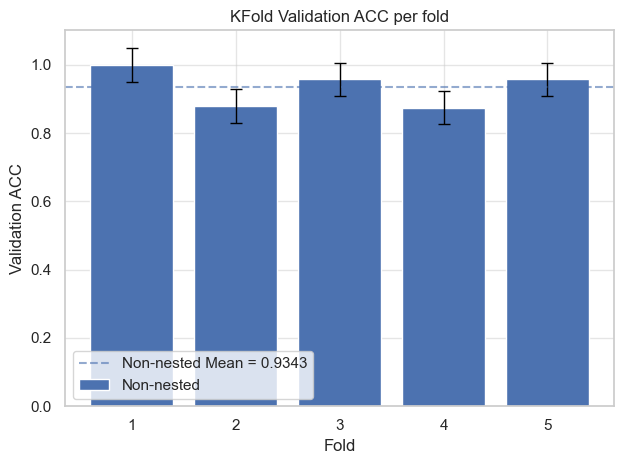

,TR,VL,|TR-VL|
Fold,,,
1,0.948454,1.000000,0.051546
2,0.969072,0.880000,-0.089072
3,0.979592,0.958333,-0.021259
4,0.959184,0.875000,-0.084184
5,0.959184,0.958333,-0.000850
MEAN,0.963097,0.934333,-0.028764
STD,0.010515,0.048860,0.052903


In [25]:
importlib.reload(cr)
for metric in ["acc"]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_summary(fold_histories, use=metric))


<h5>Hold-out</h5>
<p>A fixed hold-out split is used to visualize the training and validation learning curves, analyze the model’s convergence and generalization behavior, and identify the best epoch through early stopping.</p>

In [26]:
importlib.reload(nnc)
model_final = copy.deepcopy(model_template)

train_kf_result = nnc.train(
    model_final, HoldOutStrategy(FeatureTargetSet(X_tr, y_tr), val_ratio=0.2), # 0.1 = 10% - 0.2 = 20%
    **inner_train_params
)

Early stopping at epoch 65 (best VL loss: 0.3570)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 98
Validation      | samples: 24
Batch type      | mini-batch (8)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.sgd.SGD'> , params: {'lr': 0.02670345308569803, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.005877438905141875}
LR Decay        | params: {'mode': 'min', 'factor': 0.5, 'patience': 10, 'threshold': 0.01}
Early Stopping  | best epoch: 16 metric: loss,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------


In [27]:
importlib.reload(nnc)
epochs_kf_tr_loss = train_kf_result.epochs_tr_loss
epochs_kf_vl_loss = train_kf_result.epochs_vl_loss
epochs_kf_vl_acc = train_kf_result.epochs_vl_acc
epochs_kf_tr_acc = train_kf_result.epochs_tr_acc
epochs_kf_grad = train_kf_result.epochs_grad_norm
best_kf_epoch = train_kf_result.best_epoch

<h5>Gradient Norm</h5>
<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

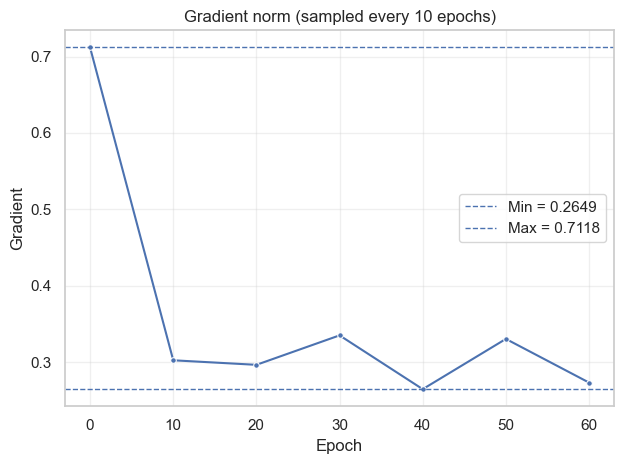

In [28]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=10)

<h5>Epoch Loss</h5>

<Figure size 640x480 with 0 Axes>

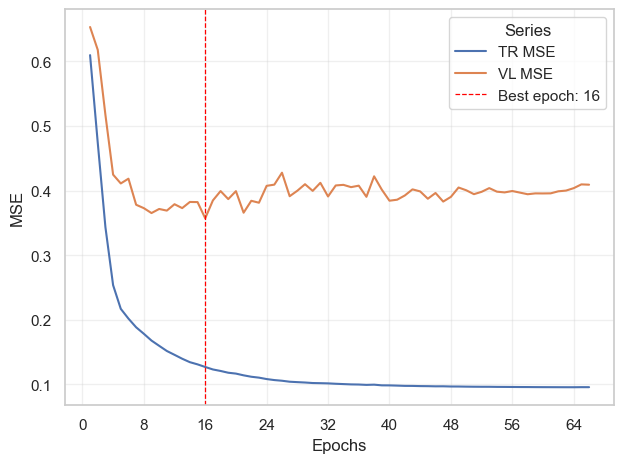

In [29]:
importlib.reload(nnc)
nnc.plot_epoch_mse(epochs_kf_tr_loss, epochs_kf_vl_loss, best_kf_epoch)

In [30]:
importlib.reload(cr)
mean, std = cr.mean_std_from_kfold(epochs_kf_vl_loss)
print(f"{mean:.4f} ± {std:.4f}")

0.4042 ± 0.0459


<Figure size 640x480 with 0 Axes>

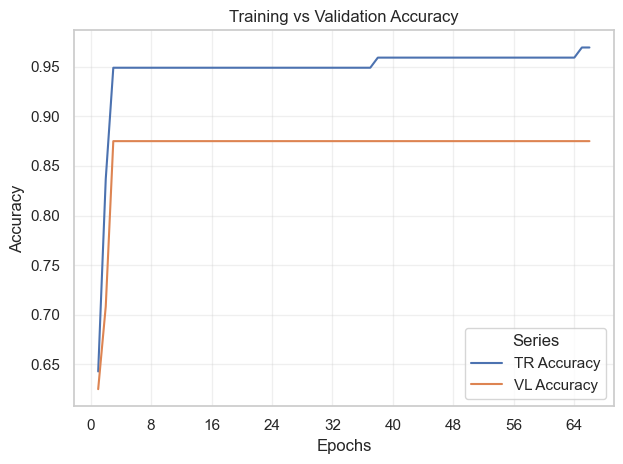

In [31]:
nnc.plot_epoch_accuracy(epochs_kf_tr_acc, epochs_kf_vl_acc)

In [32]:
from sklearn.metrics import classification_report

importlib.reload(nnc)
importlib.reload(mc)
y_pred = mc.classification_helper(model_final.predict(X_ts))
print(classification_report(y_ts, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       204
           1       1.00      0.95      0.97       228

    accuracy                           0.97       432
   macro avg       0.97      0.97      0.97       432
weighted avg       0.97      0.97      0.97       432



<h3>Best Hyperparameters</h3>
<hr/>

In [37]:
import numpy as np

final_cv_validation_mee = float(np.mean([fold.fold_vl_loss for fold in fold_histories]))
final_cv_training_mee = float(np.mean([fold.fold_tr_loss for fold in fold_histories]))
final_cv_gap = (final_cv_validation_mee - final_cv_training_mee)
final_cv_validation_mee = float(np.mean([fold.fold_vl_loss for fold in fold_histories]))
final_cv_training_mee = float(np.mean([fold.fold_tr_loss for fold in fold_histories]))
final_cv_gap = (final_cv_validation_mee - final_cv_training_mee)

print(f"Set: {monk_data_set_id}")
print(f"TRAINING_SEED: {TRAINING_SEED}")
print(f"OPTUNA_SEED: {OPTUNA_SEED}")
print(f"CV_RANDOM_STATE: {CV_RANDOM_STATE}")
print(f"Mean training MEE: {final_cv_training_mee:.4f}")
print(f"Mean CV validation MEE: {final_cv_validation_mee:.4f}")
print(f"TR–VL gap: {final_cv_gap:.4f}")
print(f"hidden layers: {final_hidden_layers}")
print(f"activation function: {final_activation}")
for key, value in inner_train_params.items(): print(f"{key}: {value}")

Set: 3
TRAINING_SEED: 1
OPTUNA_SEED: 1
CV_RANDOM_STATE: 42
Mean training MEE: 0.1108
Mean CV validation MEE: 0.2019
TR–VL gap: 0.0911
hidden layers: [4]
activation function: gelu
epochs: 1000
batch_size: 8
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.sgd.SGD'>, lr=0.02670345308569803, momentum=0.9, nesterov=True, weight_decay=0.005877438905141875)
loss_function: BCEWithLogitsLoss()
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.001
additional_metrics: {'loss': (BCEWithLogitsLoss(), <built-in function min>)}


In [33]:
print(f"set: {monk_data_set_id}")
for key, value in inner_train_params.items():
    print(f"{key}: {value}")

print(f"hidden layers: {final_hidden_layers}")

set: 3
epochs: 1000
batch_size: 8
scheduler_template: functools.partial(<class 'torch.optim.lr_scheduler.ReduceLROnPlateau'>, mode='min', factor=0.5, patience=10, threshold=0.01)
optimizer_template: functools.partial(<class 'torch.optim.sgd.SGD'>, lr=0.02670345308569803, momentum=0.9, nesterov=True, weight_decay=0.005877438905141875)
loss_function: BCEWithLogitsLoss()
early_stopping_strategy: EarlyStopping monitoring loss with patience=50, min_delta=0.001
additional_metrics: {'loss': (BCEWithLogitsLoss(), <built-in function min>)}
hidden layers: [4]
